In [1]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [2]:
DATASET_PATH = 'C:\\Users\\landa\\python notebooks\\speech'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
  tf.keras.utils.get_file(
      'Dataset-Augmented.zip',
      origin="https://drive.google.com/file/d/1WI8f-uCUzQH4Ju4kCxkGWl2YMCIFSnYY/view?usp=sharing",
      extract=True,
      cache_dir='.', cache_subdir='data')

In [3]:
commands = ['0','1','2','3','4','5','6','7','8','9']
print('Commands:', commands)

Commands: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [4]:
DATASET_PATH = 'C:\\Users\\landa\\python notebooks\\speech\\train'
data_dir = pathlib.Path(DATASET_PATH)
train_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='training')

DATASET_PATH = 'C:\\Users\\landa\\python notebooks\\speech\\test'
data_dir = pathlib.Path(DATASET_PATH)
val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=32,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='validation')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)

Found 10308 files belonging to 10 classes.
Using 8247 files for training.
Found 1105 files belonging to 10 classes.
Using 221 files for validation.

label names: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [5]:
train_ds.element_spec

(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [6]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

In [7]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [8]:
for example_audio, example_labels in train_ds.take(1):  
  print(example_audio.shape)
  print(example_labels.shape)

(64, 16000)
(64,)


In [9]:
label_names[[1,1,3,0]]

array(['1', '1', '3', '0'], dtype='<U1')

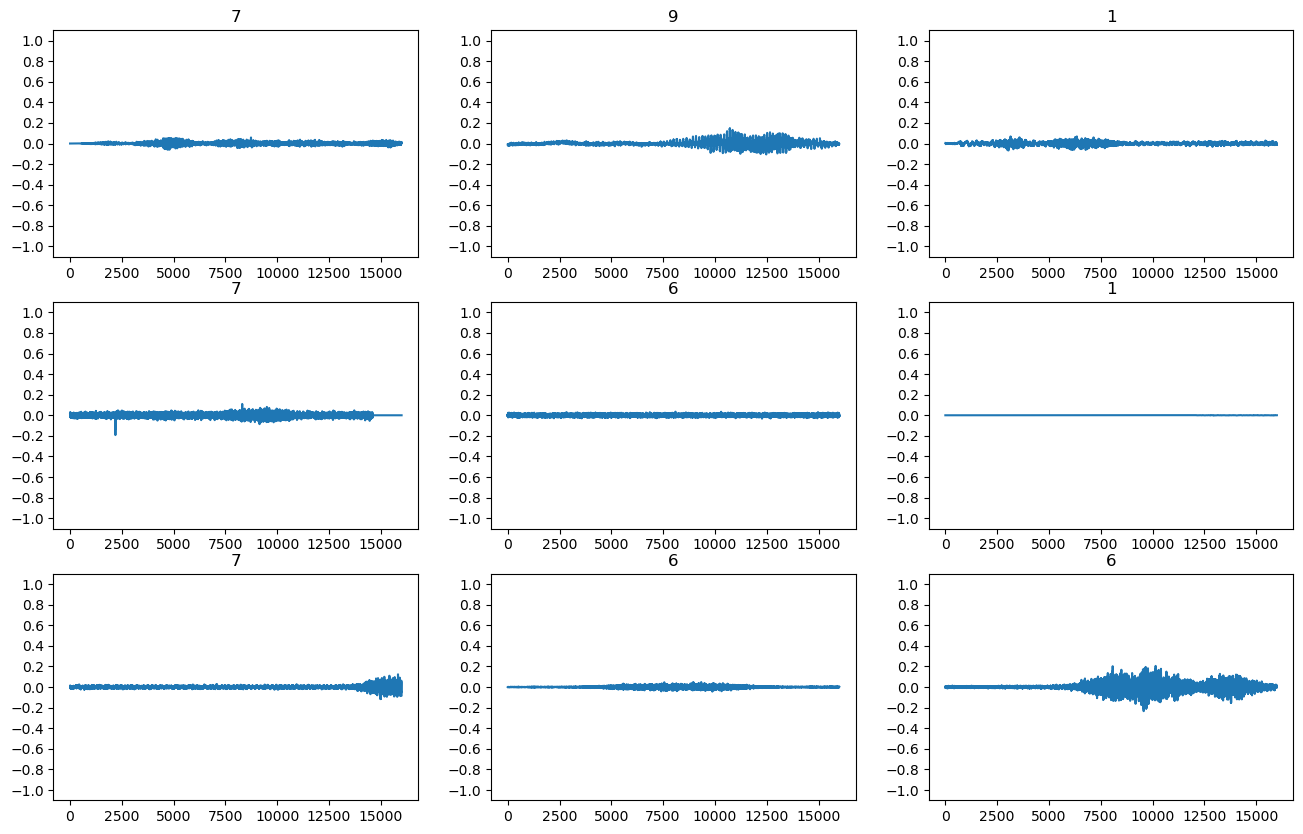

In [10]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

In [11]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

In [12]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

Label: 7
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: 9
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: 1
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


In [13]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

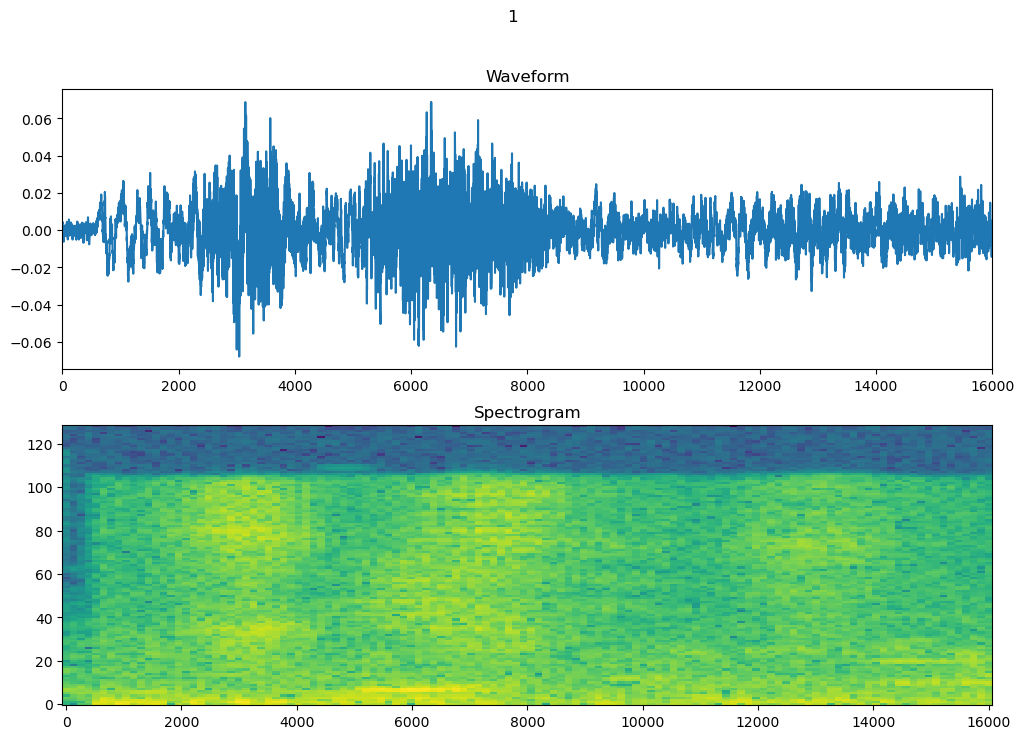

In [14]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

In [15]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [16]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

In [17]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

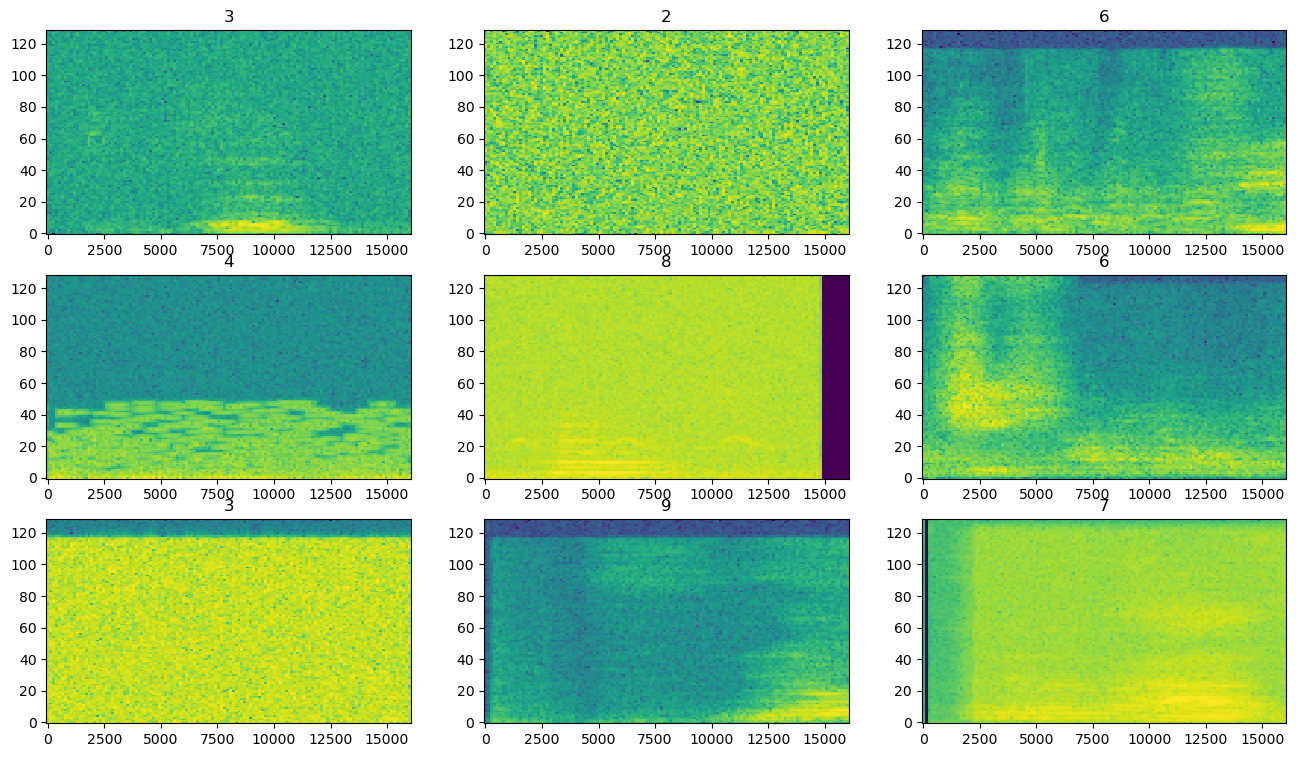

In [18]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

In [19]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

In [20]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(64, 64),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (124, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing (Resizing)                  │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ normalization (Normalization)        │ (None, 64, 64, 1)           │               3 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 652,813 (2.49 MB)

 Trainable params: 652,810 (2.49 MB)

 Non-trainable params: 3 (16.00 B)

In [21]:
from tensorflow import keras
from tensorflow.keras import callbacks

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

checkpoint_filepath = 'C:/Users/landa/python notebooks/speech/ckpt/checkpoint.model.keras'

model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath = checkpoint_filepath,
    monitor="val_accuracy",
    verbose=0,
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch"
)

In [22]:
EPOCHS = 50

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=model_checkpoint_callback
)

Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 191ms/step - accuracy: 0.1501 - loss: 2.2564 - val_accuracy: 0.4479 - val_loss: 1.6736
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 212ms/step - accuracy: 0.2349 - loss: 2.0499 - val_accuracy: 0.4167 - val_loss: 1.5206
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 207ms/step - accuracy: 0.2954 - loss: 1.9048 - val_accuracy: 0.4792 - val_loss: 1.4661
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 208ms/step - accuracy: 0.3247 - loss: 1.8242 - val_accuracy: 0.5104 - val_loss: 1.3268
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 210ms/step - accuracy: 0.3617 - loss: 1.7216 - val_accuracy: 0.5729 - val_loss: 1.2132
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 208ms/step - accuracy: 0.3765 - loss: 1.6696 - val_accuracy: 0.5729 - val_loss: 1.2341
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 28s 220ms/step - accuracy: 0.4120 - loss: 1.5838 - val_accuracy: 0.5521 - val_loss: 1.3288
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 209ms/step - accuracy: 0.4340 - loss: 1

129/129 ━━━━━━━━━━━━━━━━━━━━ 26s 204ms/step - accuracy: 0.9175 - loss: 0.2545 - val_accuracy: 0.5417 - val_loss: 4.2269


In [24]:
model.load_weights(checkpoint_filepath)

Text(0, 0.5, 'Accuracy [%]')

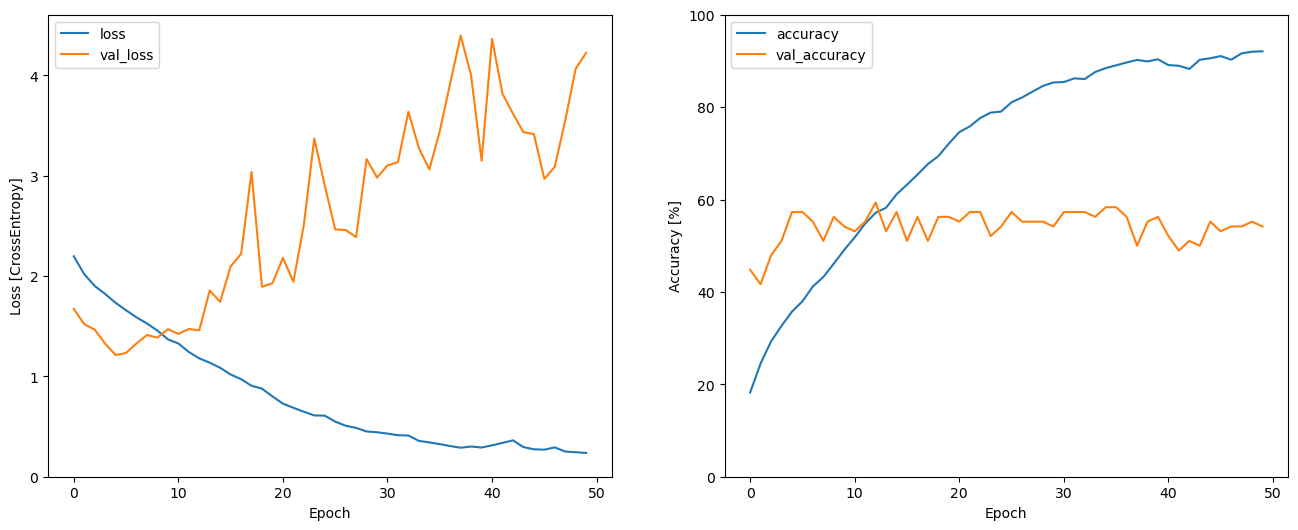

In [45]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

## Evaluate the model performance

Run the model on the test set and check the model's performance:

In [25]:
model.evaluate(test_spectrogram_ds, return_dict=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6348 - loss: 1.1556


{'accuracy': 0.6000000238418579, 'loss': 1.1720930337905884}

### Display a confusion matrix

Use a [confusion matrix](https://developers.google.com/machine-learning/glossary#confusion-matrix) to check how well the model did classifying each of the commands in the test set:


In [46]:
y_pred = model.predict(test_spectrogram_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [47]:
y_pred = tf.argmax(y_pred, axis=1)

In [48]:
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

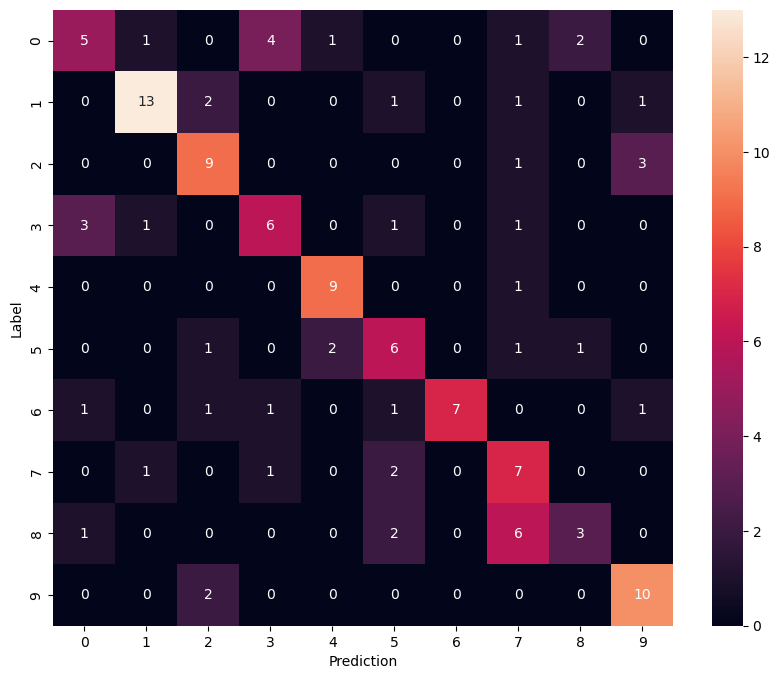

In [49]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

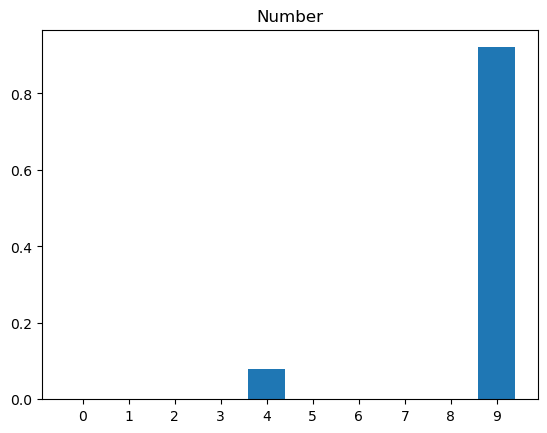

In [42]:
# sample datas were recorded by phone and their format is m4a. so first we converted them into wav.
from pydub import AudioSegment
import tensorflow as tf

audio = AudioSegment.from_file("C:/Users/landa/python notebooks/speech/recorded audio/Speech 9.m4a")

audio = audio.set_channels(1).set_frame_rate(16000)

audio.export("C:/Users/landa/python notebooks/speech/recorded audio/Speech_9_converted.wav", format="wav")

x = 'C:/Users/landa/python notebooks/speech/recorded audio/Speech_9_converted.wav'
x = tf.io.read_file(x)
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000)
x = tf.squeeze(x, axis=-1)
waveform = x
x = get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['0','1','2','3','4','5','6','7','8','9']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('Number')
plt.show()

display.display(display.Audio(waveform, rate=16000))

In [ ]:
# label 0 --> prediction 0
# label 1 --> prediction 1
# label 2 --> prediction 2
# label 3 --> prediction 3
# label 4 --> prediction 4
# label 5 --> prediction 7
# label 6 --> prediction 6
# label 7 --> prediction 7
# label 8 --> prediction 8
# label 9 --> prediction 9

## Connecting to microphone

In [44]:
import pyaudio
import tensorflow as tf
import keyboard
from scipy.signal import spectrogram

CHUNK = 16000
FORMAT = pyaudio.paInt16 
CHANNELS = 1  
RATE = 16000

x_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

def get_spectrogram(waveform):
    waveform = tf.convert_to_tensor(waveform, dtype=tf.float32)
    spectrogram = tf.signal.stft(waveform, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    return spectrogram

audio = pyaudio.PyAudio()
stream = audio.open(format=FORMAT, 
                    channels=CHANNELS, 
                    rate=RATE, 
                    input=True, 
                    frames_per_buffer=CHUNK)

print("Listening for words... Press 'q' to stop.")

try:
    while True:
        audio_data = stream.read(CHUNK, exception_on_overflow=False)
        
        waveform = np.frombuffer(audio_data, dtype=np.int16).astype(np.float32) / 32768.0 

        spectrogram = get_spectrogram(waveform)

        input_data = spectrogram[tf.newaxis, ...]

        prediction = model(input_data)
        predicted_label = x_labels[tf.argmax(prediction[0]).numpy()]

        print(f"Predicted Word: {predicted_label}")

        if keyboard.is_pressed('q'):
            print("\nStopped listening.")
            break

except KeyboardInterrupt:
    print("\nInterrupted by user.")

stream.stop_stream()
stream.close()
audio.terminate()

Listening for words... Press 'q' to stop.
Predicted Word: 2
Predicted Word: 1
Predicted Word: 1
Predicted Word: 1
Predicted Word: 8
Predicted Word: 0
Predicted Word: 2
Predicted Word: 6
Predicted Word: 0
Predicted Word: 0
Predicted Word: 6
Predicted Word: 6
Predicted Word: 5
Predicted Word: 6
Predicted Word: 6
Predicted Word: 8
Predicted Word: 6
Predicted Word: 5
Predicted Word: 5
Predicted Word: 7
Predicted Word: 6
Predicted Word: 6
Predicted Word: 3
Predicted Word: 5
Predicted Word: 6
Predicted Word: 6
Predicted Word: 6
Predicted Word: 0
Predicted Word: 2

Stopped listening.
